<a href="https://colab.research.google.com/github/Sia-Kuznetsova/python-portfolio/blob/main/EDA_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Часть 1

### Загрузка данных

In [1]:
!wget https://drive.google.com/uc?id=1IhdoUFdSGdk6Hc0KC-lFHDop0X9M7M4t -O housing.csv

--2026-03-24 15:22:19--  https://drive.google.com/uc?id=1IhdoUFdSGdk6Hc0KC-lFHDop0X9M7M4t
Resolving drive.google.com (drive.google.com)... 172.217.194.101, 172.217.194.100, 172.217.194.113, ...
Connecting to drive.google.com (drive.google.com)|172.217.194.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1IhdoUFdSGdk6Hc0KC-lFHDop0X9M7M4t [following]
--2026-03-24 15:22:20--  https://drive.usercontent.google.com/download?id=1IhdoUFdSGdk6Hc0KC-lFHDop0X9M7M4t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.12.132, 2404:6800:4003:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.12.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2515206 (2.4M) [application/octet-stream]
Saving to: ‘housing.csv’

housing.csv         100%[===================>]   2.40M  --.-KB/s    in 0.03s   

2026-03-24 15:22:22 (95.7 MB/s

Импорт библиотек

In [2]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [3]:
path='housing.csv'
df = pd.read_csv(path, sep=',')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Изучение стоимости недвижимости

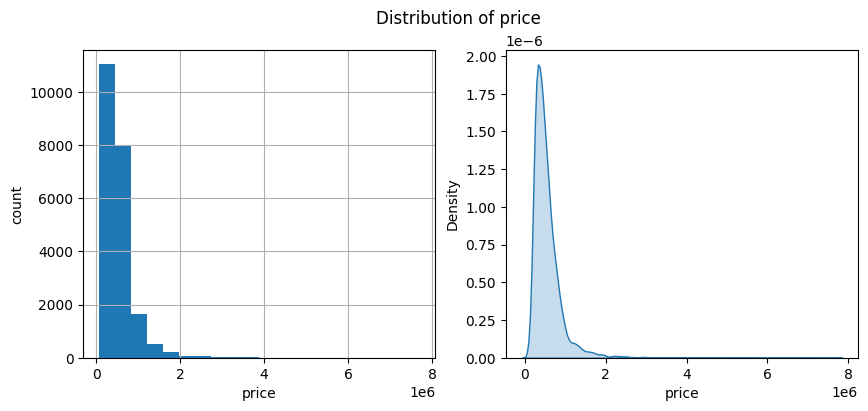

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
df['price'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('price')

plt.subplot(122)
sns.kdeplot(df['price'], shade=True, legend=False)
plt.xlabel('price')

plt.suptitle('Distribution of price')
plt.show()

Посмотрим на основные характеристики (среднее, медиана, мода)

In [5]:
price_mean = round(df['price'].mean(),2)
price_mode = df['price'].mode()[0]
price_median = df['price'].median()
print('mean =', price_mean)
print('mode =', price_mode)
print('median =', price_median)

mean = 540088.14
mode = 350000.0
median = 450000.0


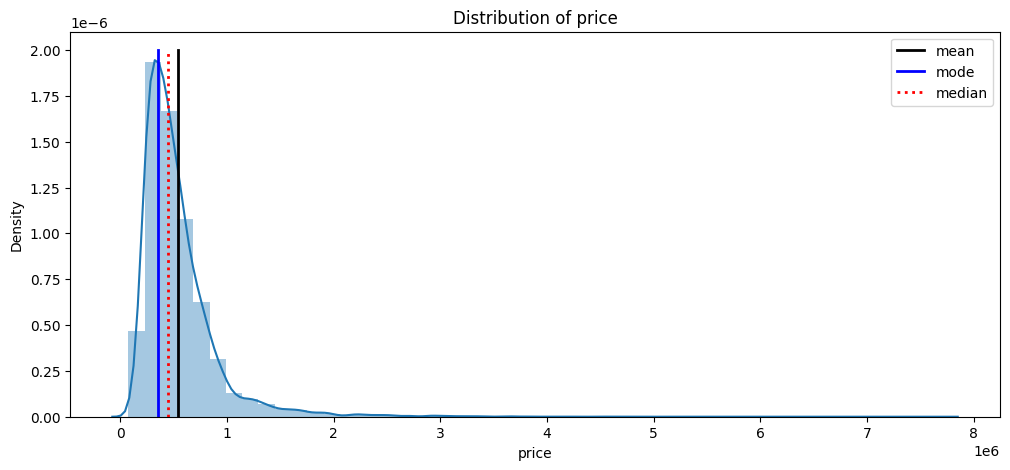

In [6]:
plt.figure(figsize=(12,5))
sns.distplot(df['price'], bins=50)
y = np.linspace(0, 0.000002, 2)
plt.plot([price_mean]*2, y, label='mean', linestyle='-', c='0', linewidth=2)
plt.plot([price_mode]*2, y, label='mode', linestyle='-', c='b', linewidth=2)
plt.plot([price_median]*2, y, label='median', linestyle=':', c='r', linewidth=2)
plt.title('Distribution of price')
plt.legend()
plt.show()

Видно, что есть дома цена которых значительно выше средней, но таких домов мало. Из-за этого наш груфик как бы смещен влево. Чтобы улучшить визуальное понимание данных нужно сделать преобразования. Какие я рассмотрела варианты:
1. Удалить данные о дорогих домах - но тогда, я потеряю много данных;
2. Взять и заменить стоимость дорогих домов на значение медианы - я так сделала и поняла, что тогда я вообще ломаю данные (потому что площадь домов будет неправильно соотноситься с ценой и вообще на гистограмме получился большой скачок в месте медианы);
3. Разделить данные на две части - дорогие и дешевые дома - я думаю это был бы хороший вариант, но тогда было бы два различных анализа;
4. В интернете я нашла вариант - взять логарифм от стоимости и работать с ним - на уроке был момент о том, что иногда надо использовать не сырые данные а результат мат.операций.

Я выбрала 4 вариант.

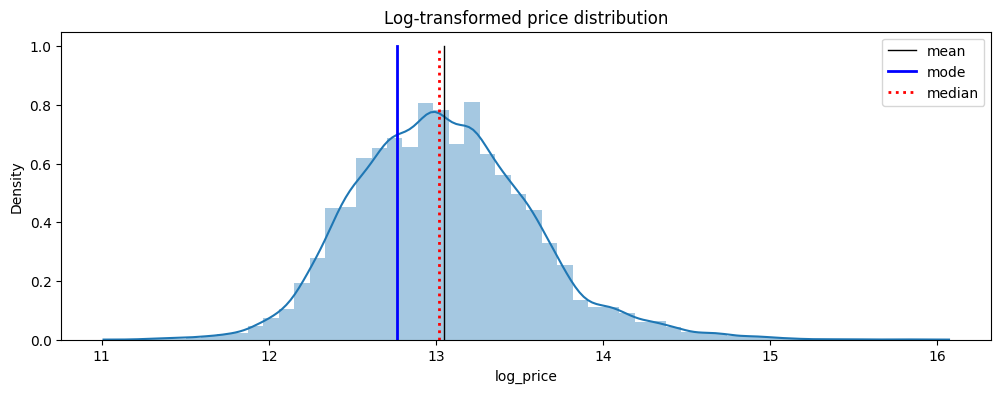

In [7]:
df['log_price'] = np.log(df['price'])

plt.figure(figsize=(12,4))
sns.distplot(df['log_price'], bins=50)

price_mean_log = round(df['log_price'].mean(),2)
price_mode_log = df['log_price'].mode()[0]
price_median_log = df['log_price'].median()

y = np.linspace(0, 1, 2)
plt.plot([price_mean_log]*2, y, label='mean', linestyle='-', c='0', linewidth=1)
plt.plot([price_mode_log]*2, y, label='mode', linestyle='-', c='b', linewidth=2)
plt.plot([price_median_log]*2, y, label='median', linestyle=':', c='r', linewidth=2)

plt.title("Log-transformed price distribution")
plt.legend()
plt.show()

Так уже выглядит намного лучше, но я хочу посмотреть график box plot и проверить на выбросы

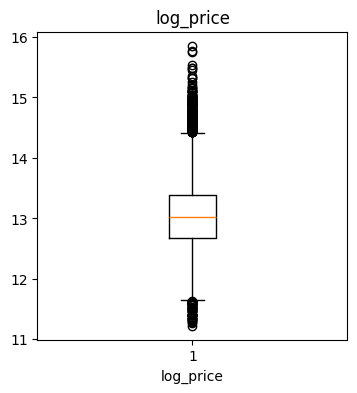

In [8]:
plt.figure(figsize=(4,4))
plt.boxplot(df['log_price'])
plt.xlabel('log_price')
plt.title('log_price')
plt.show()

Выбросы есть, я хочу посмотреть сколько их и могу ли я выбросить эти данные не потеряв большое кол-во данных

In [9]:
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['log_price'] < lower_bound) | (df['log_price'] > upper_bound)]
n_outliers = outliers.shape[0]
percent_outliers = n_outliers / df.shape[0] * 100

print(f"Количество выбросов: {n_outliers}")
print(f"Процент выбросов: {percent_outliers:.2f}%")

Количество выбросов: 333
Процент выбросов: 1.54%


Процент выбросов от всех данных меньше 2 процентов, поэтому я решила их удалить

In [10]:
df = df[(df['log_price'] > lower_bound) & (df['log_price'] < upper_bound)]

Посмотрим на обновленный график box plot

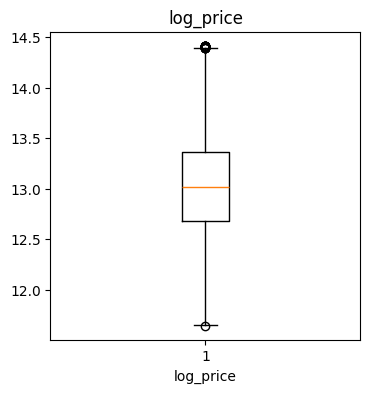

In [11]:
plt.figure(figsize=(4,4))
plt.boxplot(df['log_price'])
plt.xlabel('log_price')
plt.title('log_price')
plt.show()

Супер, так стало намного красивее. Посмотрим заново на гистограмму

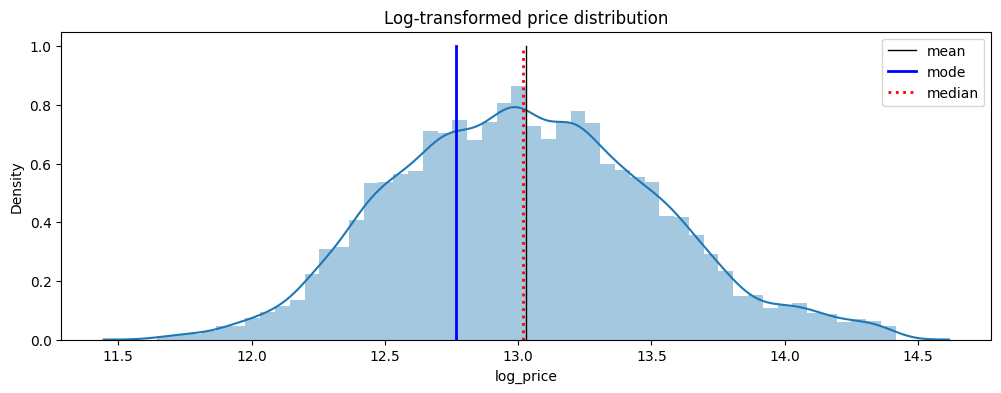

In [12]:
df['log_price'] = np.log(df['price'])

plt.figure(figsize=(12,4))
sns.distplot(df['log_price'], bins=50)

price_mean_log = round(df['log_price'].mean(),2)
price_mode_log = df['log_price'].mode()[0]
price_median_log = df['log_price'].median()

y = np.linspace(0, 1, 2)
plt.plot([price_mean_log]*2, y, label='mean', linestyle='-', c='0', linewidth=1)
plt.plot([price_mode_log]*2, y, label='mode', linestyle='-', c='b', linewidth=2)
plt.plot([price_median_log]*2, y, label='median', linestyle=':', c='r', linewidth=2)

plt.title("Log-transformed price distribution")
plt.legend()

Получилось красивое распределение. Среднее очень близко к медиане, но вот мода отконяется влево - это говорит о том, что более дешевые дома встречались ваще.

## Изучение распределения квадратуры жилой площади

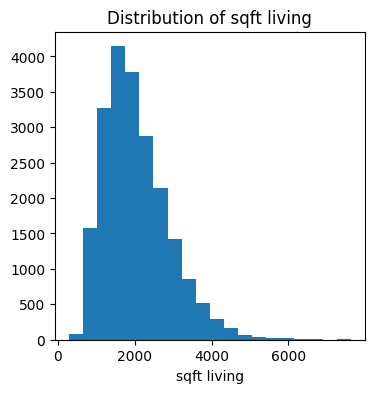

In [13]:
gr_1 = df['sqft_living'].hist(figsize=(4,4), bins=20, grid=0)
gr_1.set_title('Distribution of sqft living')
gr_1.set_xlabel('sqft living');

Большая часть квартир имеет площать от 500 до 3000 ft2 (примерно). Есть дома с площадью до 7к квадратных футов, но по кол-ву их не много. Посмотрим на том, есть ли корреляция между (жилой площадью & ценой домов) и (жилой площадью &log_цены)

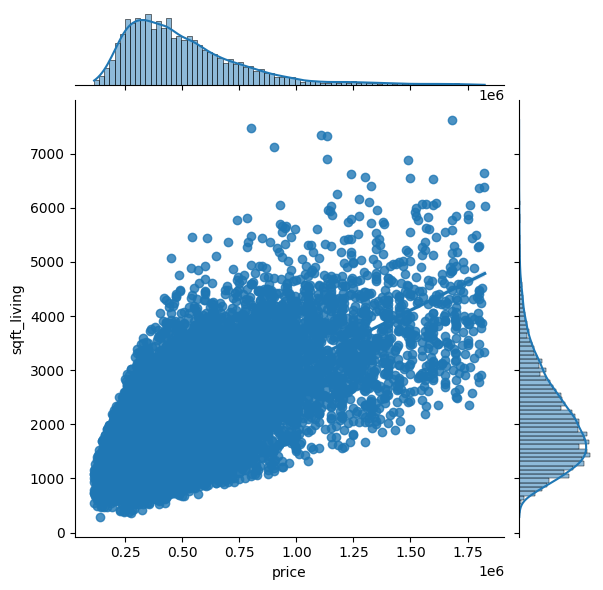

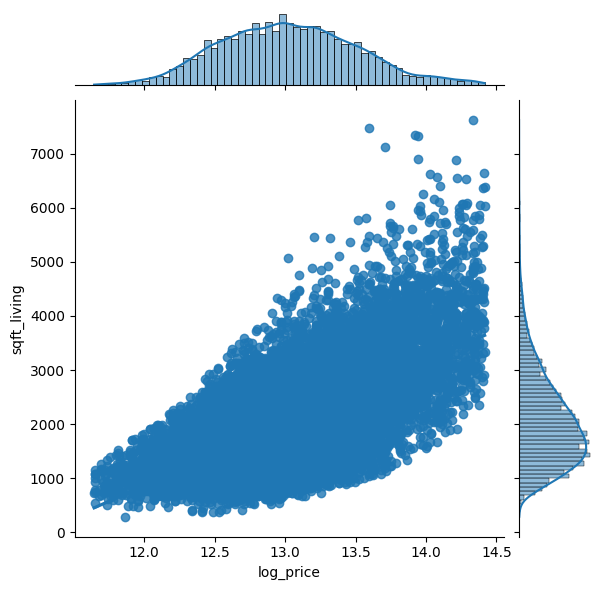

In [14]:
sns.jointplot(x=df['price'], y=df['sqft_living'], kind='reg')
sns.jointplot(x=df['log_price'], y=df['sqft_living'], kind='reg');

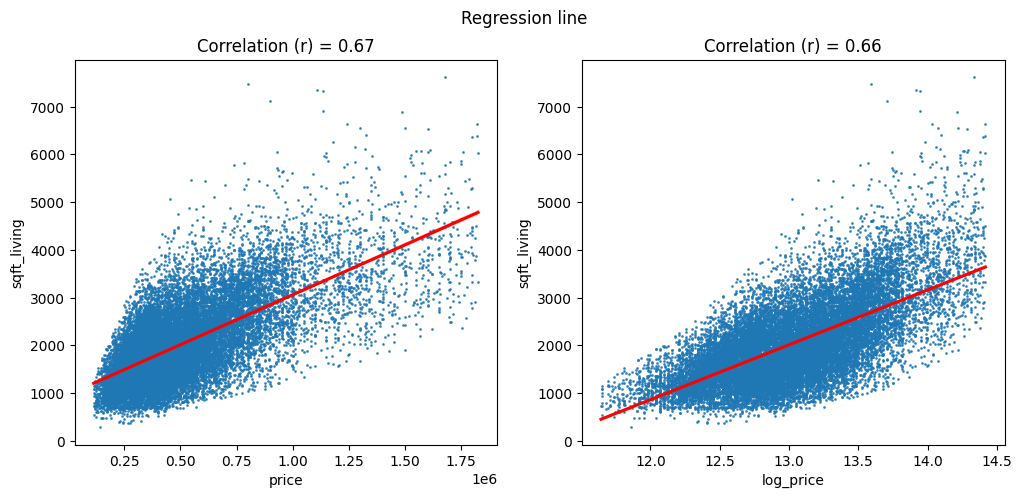

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.regplot(x=df['price'], y=df['sqft_living'],  scatter_kws={'s':1}, line_kws={'color':'red'})
rg_1 = round(df['price'].corr(df['sqft_living']),2)
plt.title(f"Correlation (r) = {rg_1}")

plt.subplot(122)
sns.regplot(x=df['log_price'], y=df['sqft_living'], scatter_kws={'s':1}, line_kws={'color':'red'})
rg_2 = round(df['log_price'].corr(df['sqft_living']),2)
plt.title(f"Correlation (r) = {rg_2}")

plt.suptitle('Regression line')
plt.show()

Ну и тут я пока не знаю какой делать вывод. Видно что коэффициент регрессии примерно одинаковый. При этом распределение точек на графике отличается.

**Поиск выбросов с помощью box plot**

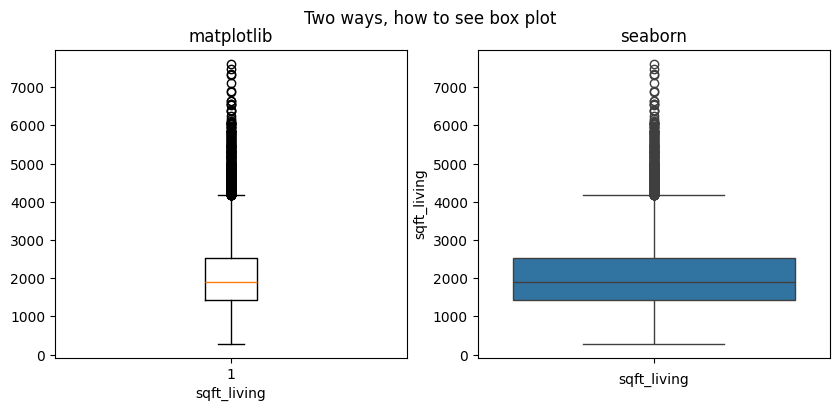

In [16]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.boxplot(df['sqft_living'])
plt.xlabel('sqft_living')
plt.title('matplotlib')

plt.subplot(122)
sns.boxplot(df['sqft_living'], whis=1.5)
plt.xlabel('sqft_living')
plt.title('seaborn')

plt.suptitle('Two ways, how to see box plot')
plt.show()

Найдем значение верхней границы верхнего "уса"

In [17]:
q_25 = np.quantile(df['sqft_living'], q=0.25)
q_75 = np.quantile(df['sqft_living'], q=0.75)
temp = 1.5 * (q_75-q_25)
res = q_75 + temp
print('Top value is - ', res)

Top value is -  4170.0


Посмотрим лучше сколько всего выбросов получилось

In [18]:
outliners = df.loc[df['sqft_living'] > 4170, 'sqft_living']
amount_of_outliners = outliners.shape[0]
percent_outliers = amount_of_outliners / df.shape[0] * 100
print(round(percent_outliers,2),'%')

2.06 %


2 процента данных - я думаю мы можех их выбросить и при этом не потерять в ценности всей таблицы.

In [19]:
print(df.shape)
df = df[~(df['sqft_living']>4170)]
print(df.shape)

(21280, 22)
(20842, 22)


И теперь снова посмотрим на box plot и на графики кореляции.

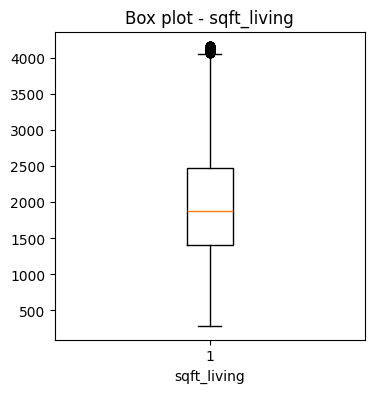

In [20]:
plt.figure(figsize=(4,4))

plt.boxplot(df['sqft_living'])
plt.xlabel('sqft_living')
plt.title('Box plot - sqft_living')

plt.show()

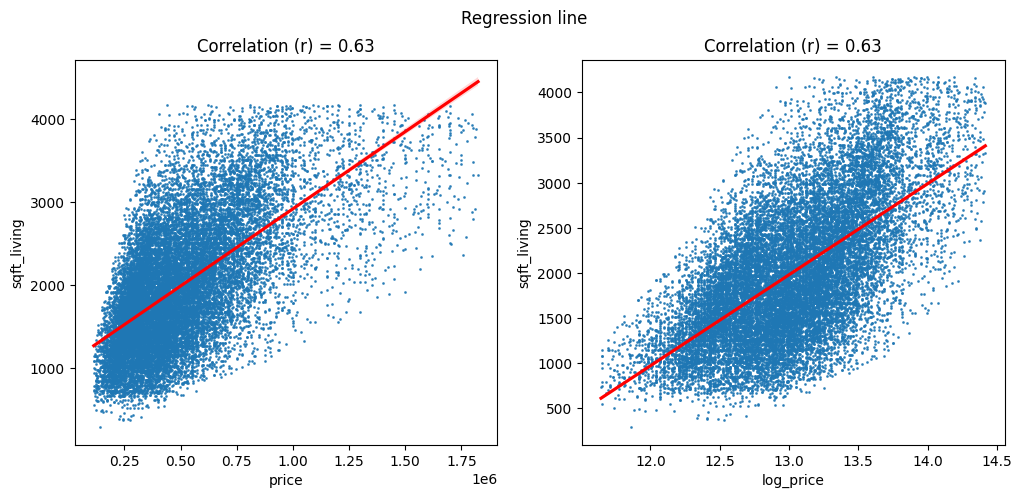

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.regplot(x=df['price'], y=df['sqft_living'],  scatter_kws={'s':1}, line_kws={'color':'red'})
rg_1 = round(df['price'].corr(df['sqft_living']),2)
plt.title(f"Correlation (r) = {rg_1}")

plt.subplot(122)
sns.regplot(x=df['log_price'], y=df['sqft_living'], scatter_kws={'s':1}, line_kws={'color':'red'})
rg_2 = round(df['log_price'].corr(df['sqft_living']),2)
plt.title(f"Correlation (r) = {rg_2}")

plt.suptitle('Regression line')
plt.show()

О, вот так вообще красиво стало. Особенно мне нравится правый график

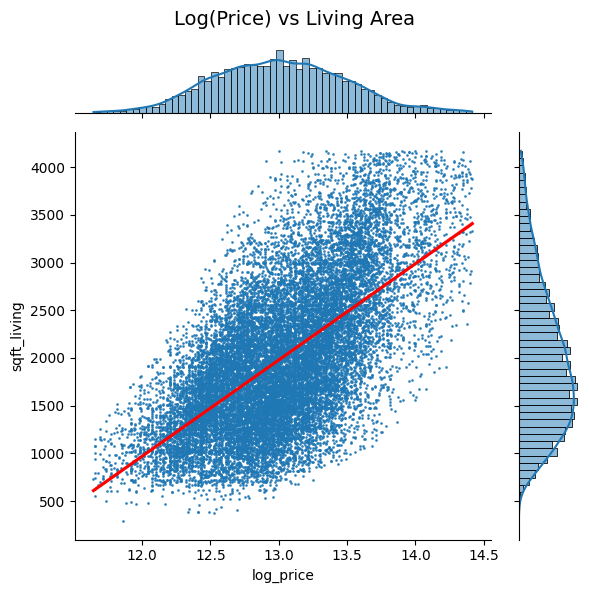

In [22]:
j_plot = sns.jointplot(
    x=df['log_price'],
    y=df['sqft_living'],
    kind='reg',
    scatter_kws={'s':1},
    line_kws={'color':'red'})
j_plot.fig.suptitle("Log(Price) vs Living Area", fontsize=14)
j_plot.fig.tight_layout()
# j_plot.fig.subplots_adjust(top=0.92)

Исходя из полученных графиком можно сделать вывод что между двусмя факторами (log(price) & sqft_living) есть положительная корреляция.

## Изучение распределения года постройки

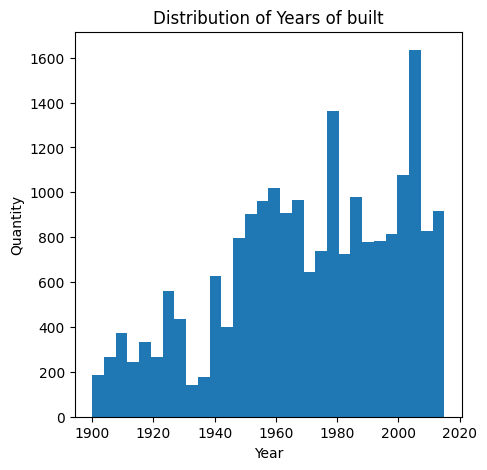

In [23]:
df['yr_built'].hist(figsize=(5,5), bins=30, grid=False)
plt.xlabel('Year')
plt.ylabel('Quantity')
plt.title('Distribution of Years of built');

Из графика видно что примерно в 1930 годы было спад строительства. Пик строительства домов наблюдается в 2010 годы.

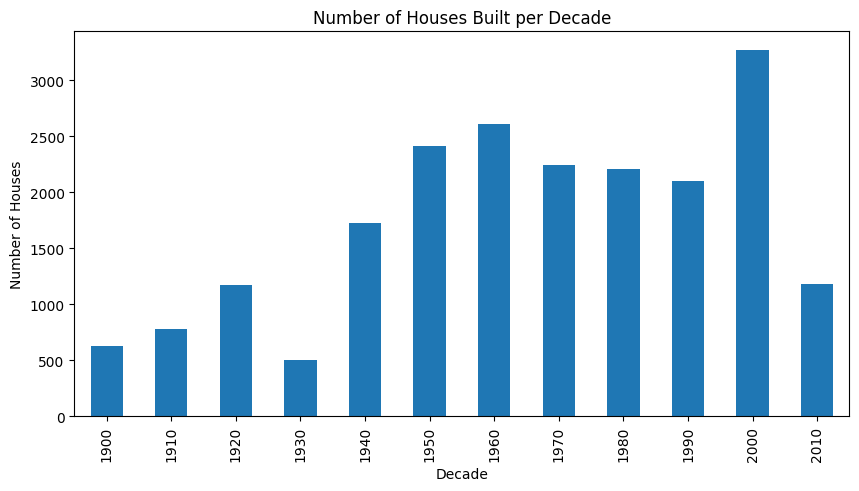

In [24]:
df['decade'] = (df['yr_built']//10)*10
decade_counts = df['decade'].value_counts().sort_index()
decade_counts.plot(kind='bar', figsize=(10,5))
plt.xlabel('Decade')
plt.ylabel('Number of Houses')
plt.title('Number of Houses Built per Decade')
plt.show()


Если посмотреть по десятилетиям становится видно что в 1930 был очевидный спад, но дальше снова был рост строительства. В 2000 годы было построено больше всего домов.

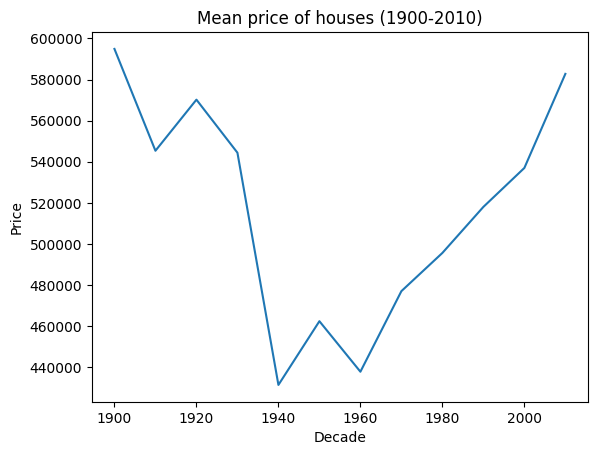

In [25]:
df.groupby('decade')['price'].mean().plot(kind='line')
plt.xlabel('Decade')
plt.ylabel('Price')
plt.title('Mean price of houses (1900-2010)')
plt.show()

По графику видно, что цены на старые дома и новые дома выше, чем цены на дома построенные в 1940-1960 гг.

In [26]:
df['age']=2025-df['yr_built']
# далее попробую построить карту, на которой будет видно старые и новые дома

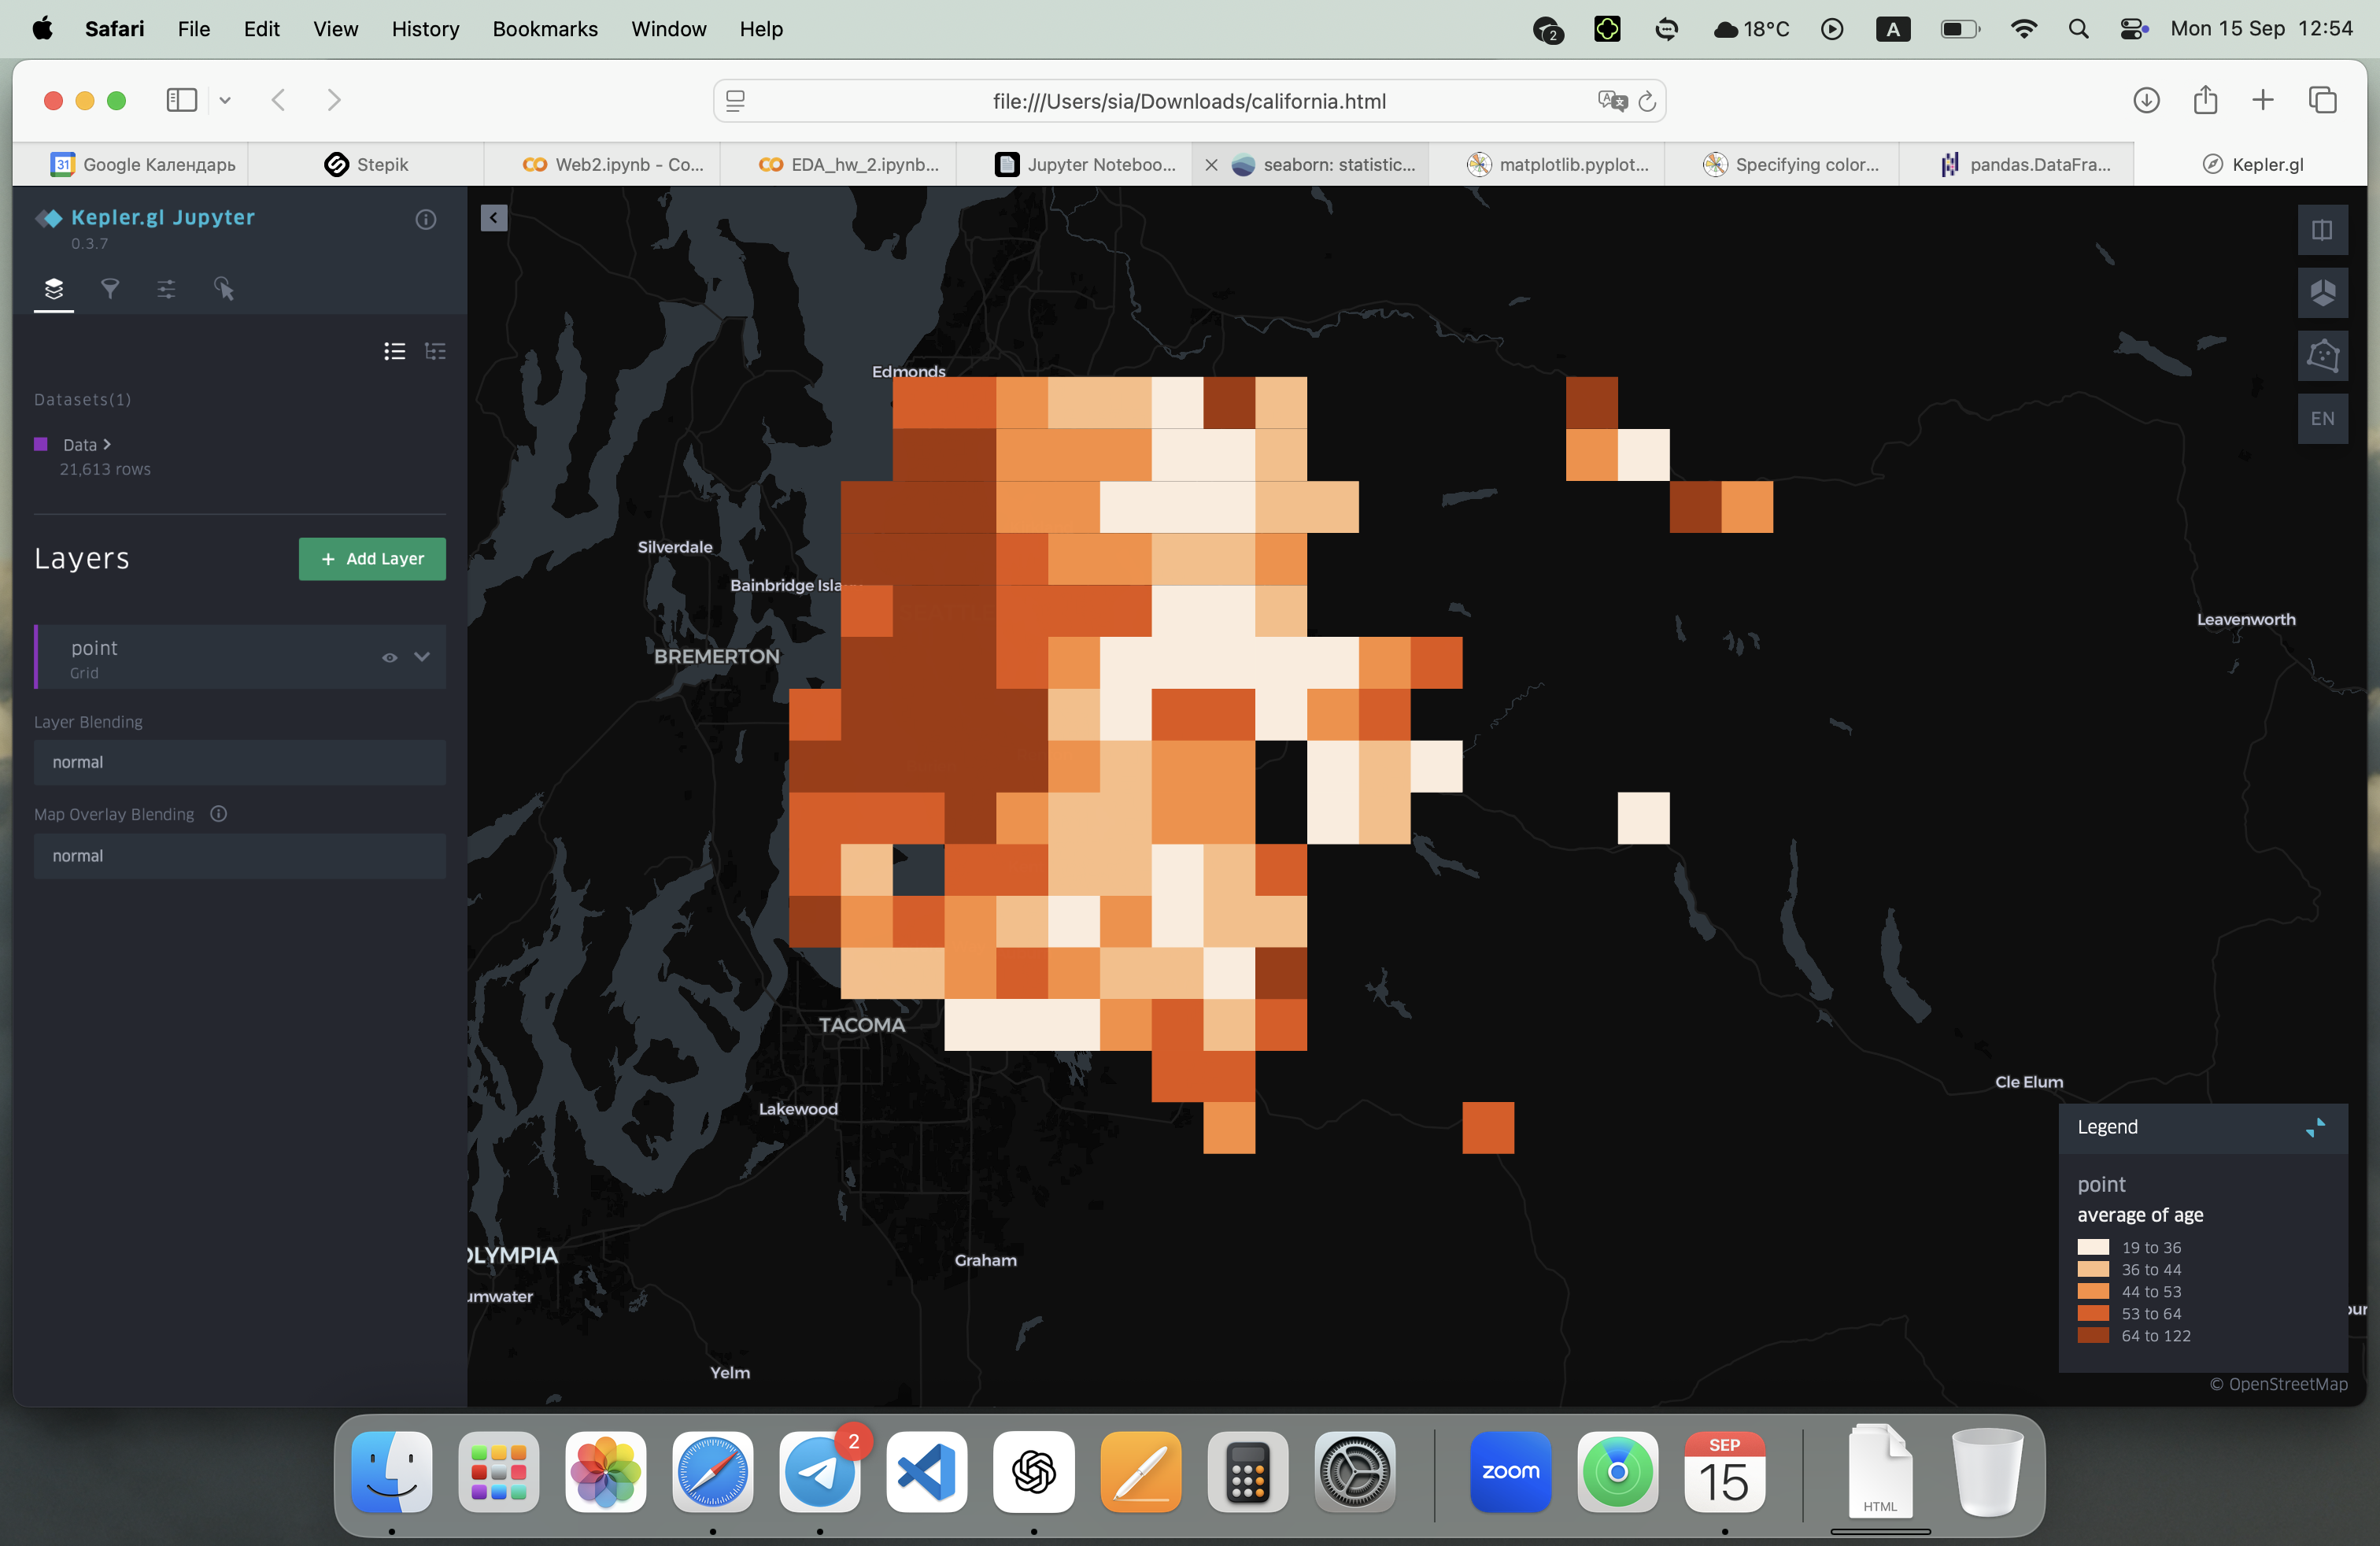

Получилась вот такая сетка распределения - чем темнее цвет - тем старше в этом районе дома. Видно что в цем застройка начиналась с берега и дальше уходила вглубь материка. (Сами шаги я удалила, потому что очень долго отрабатывали)

# Часть 2

## Изучение распределения домов от наличия вида на набережную


Как такового признака - вид на набережную в таблице я не нашла. Но я попробую его посчитать. Возьму дома у которых признак waterfront=1 (есть набережная) и посмотрю критерий view.

In [27]:
counts = df['waterfront'].value_counts()
counts

,count
waterfront,
0,20744
1,98


Всего 98 домов имеют набережную.

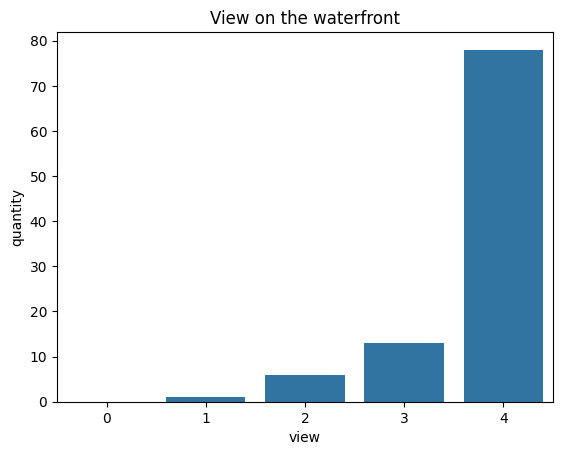

In [28]:
counts = df.groupby('view')['waterfront'].sum()
sns.barplot(x=counts.index, y=counts.values)
plt.ylabel('quantity')
plt.title('View on the waterfront')
plt.show()

БольшАя часть домов у которых есть набережная имеют отличный вид.

## Изучение распределения этажей домов


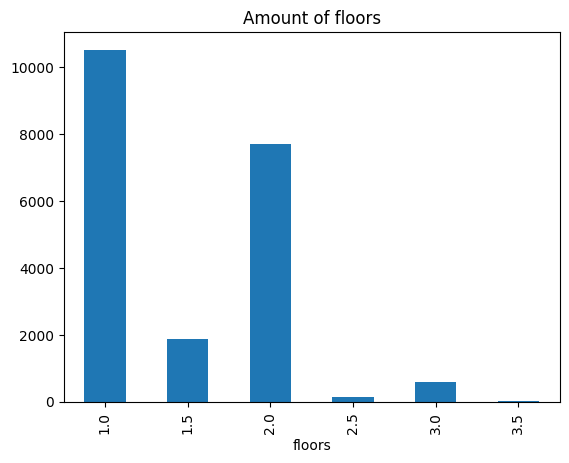

In [29]:
counts = df['floors'].value_counts().sort_index()
counts.plot(kind='bar', title='Amount of floors');

Больше всего - одноэтажных домов и двухэтажных.

## Изучение распределения состояния домов

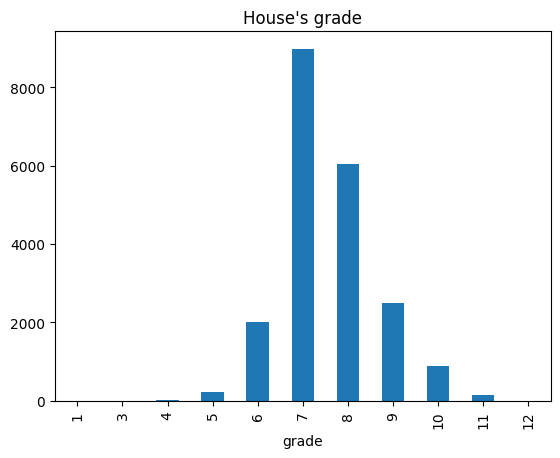

In [30]:
counts = df['grade'].value_counts().sort_index()
counts.plot(kind='bar', title="House's grade");

Наиболее часто встречающаяся оценка - 7. Так же много домов имеют оценку -6, 8, 9 и 10.

# 3 Задание

## Исследование, какие характеристики недвижимости влияют на стоимость недвижимости.

Для удобства создам таблицу для матрицы корреляций.

In [31]:
df_corr = df.drop(columns=['id', 'date','yr_built', 'price', 'decade'])
df_corr.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price,age
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,0,98178,47.5112,-122.257,1340,5650,12.309982,70
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1991,98125,47.7210,-122.319,1690,7639,13.195614,74
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,0,98028,47.7379,-122.233,2720,8062,12.100712,92
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,0,98136,47.5208,-122.393,1360,5000,13.311329,60
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,0,98074,47.6168,-122.045,1800,7503,13.142166,38


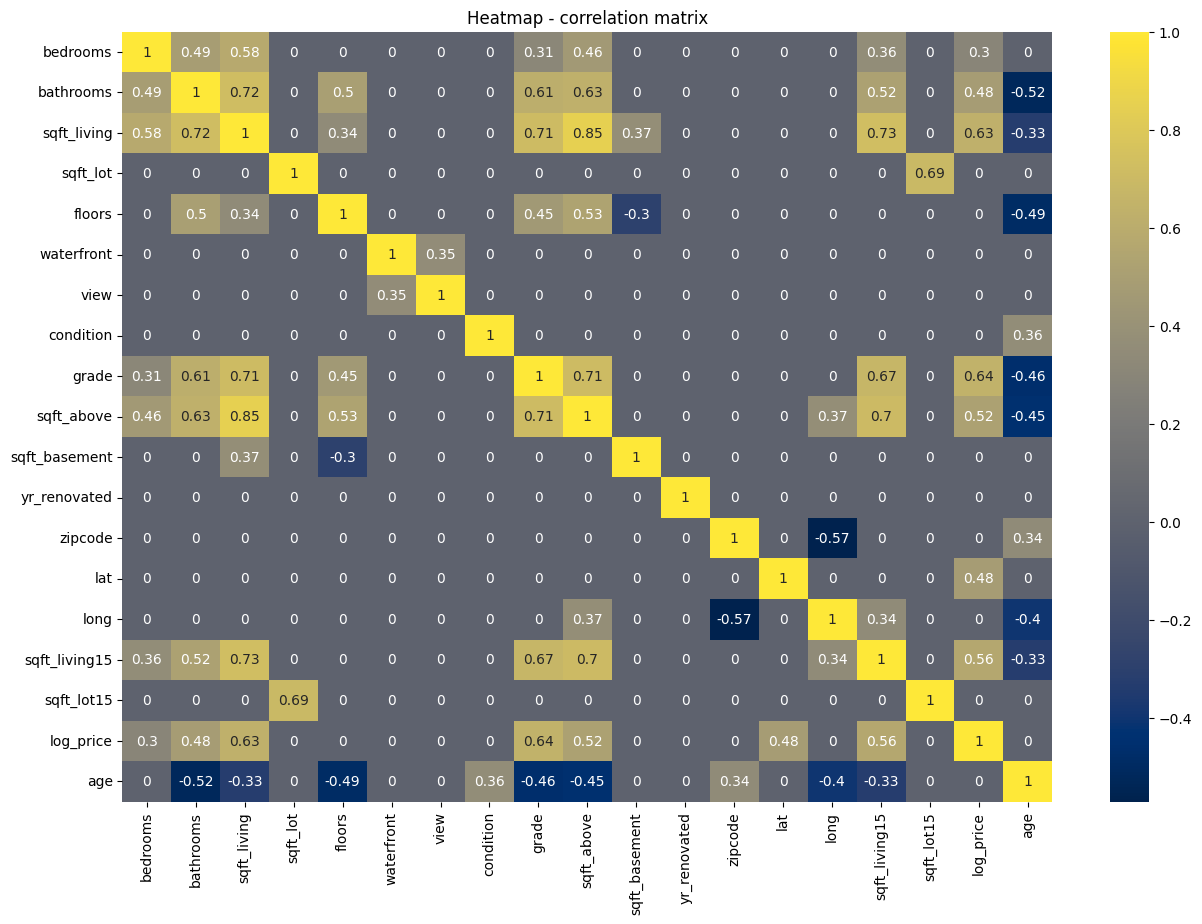

In [32]:
plt.figure(figsize=(15, 10))

corr_matrix = df_corr.corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.3] = 0

sns.heatmap(corr_matrix, annot=True, cmap='cividis')

plt.title('Heatmap - correlation matrix')
plt.show()

Я оставила только логарифм цены. На него сильнее всего влияют: жилая площадь, оценка дома, показатель sqft_living15. Оценку зависимости цены от площади я уже проводила выше.

corr= 0.64


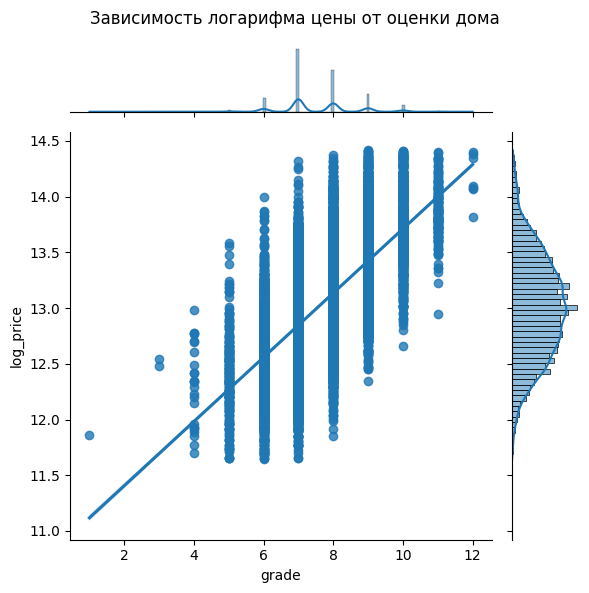

In [33]:
grid = sns.jointplot(x=df['grade'], y=df['log_price'], kind='reg')
print('corr=', round(df['log_price'].corr(df['grade']),2))

grid.fig.suptitle('Зависимость логарифма цены от оценки дома')
grid.fig.tight_layout()
plt.show()

Есть положительная корреляция между оценкой дома и логарифмом его цены.

corr= -0.05


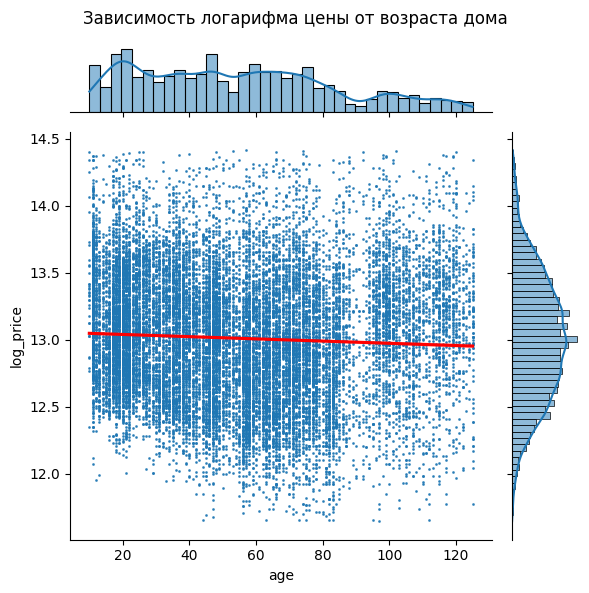

In [34]:
grid = sns.jointplot(x=df['age'],
                     y=df['log_price'],
                     kind='reg',
                     scatter_kws={'s': 1},
                     line_kws={'color': 'red'})

print('corr=', round(df['log_price'].corr(df['age']),2))

grid.fig.suptitle('Зависимость логарифма цены от возраста дома')
grid.fig.tight_layout()
plt.show()

Что интересно - корреляция между возрастом и ценой дома - практичестви нулевая. Т.е. нет такого, что чем дом новее тем он дороже или наоборот.

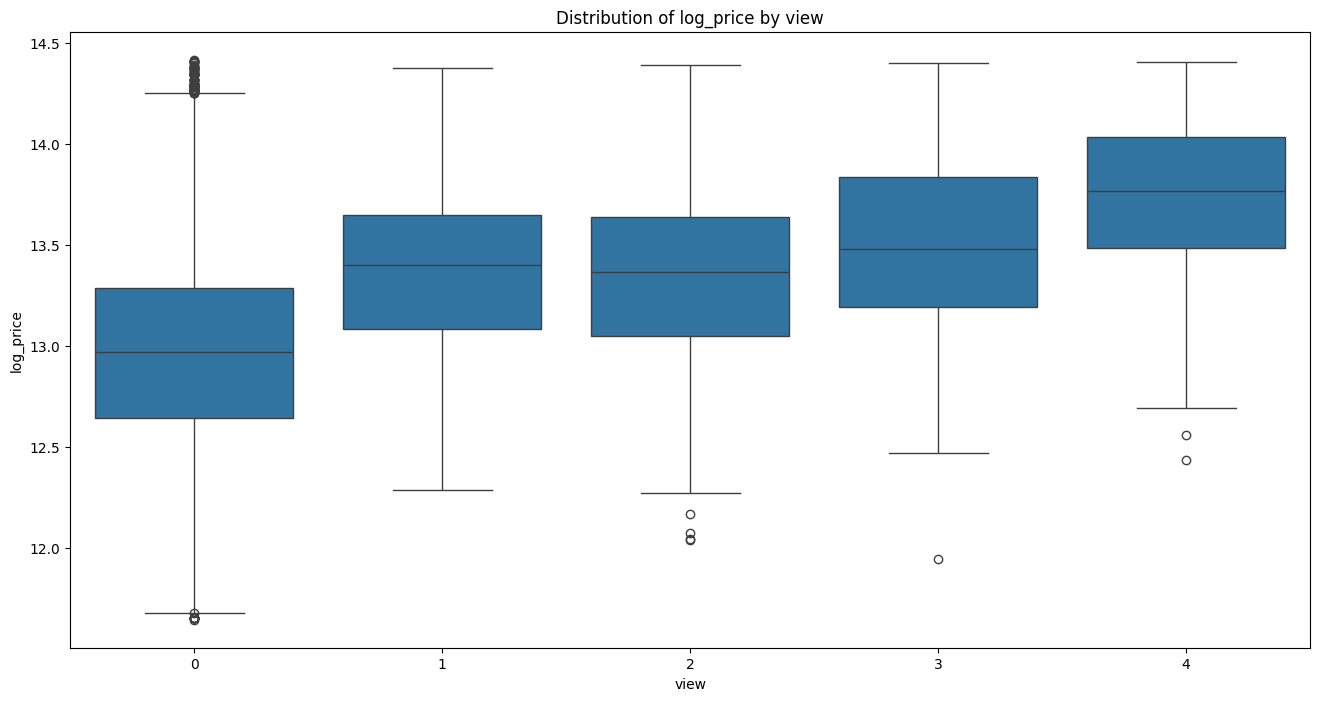

In [35]:
plt.figure(figsize=(16, 8))

sns.boxplot(x=df['view'], y=df['log_price'], whis=1.5)

plt.xlabel('view')
plt.ylabel('log_price')
plt.title('Distribution of log_price by view')
plt.show()

Видно, что цена растет в зависимости от того, какой вид. Чем лучше вид - тем выше цена.